Part 1: Affine Transformations
Step 1: Translation (Shifting an Image)

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

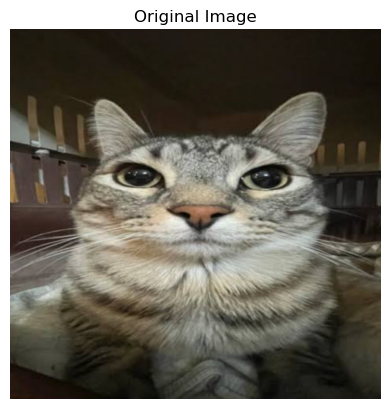

Original shape: (1077, 1080, 3)


In [2]:
# Read image
image = cv2.imread('cat.png')

# Convert BGR to RGB for correct display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

(h, w) = image.shape[:2]

plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

print("Original shape:", image.shape)

Step 1: Translation

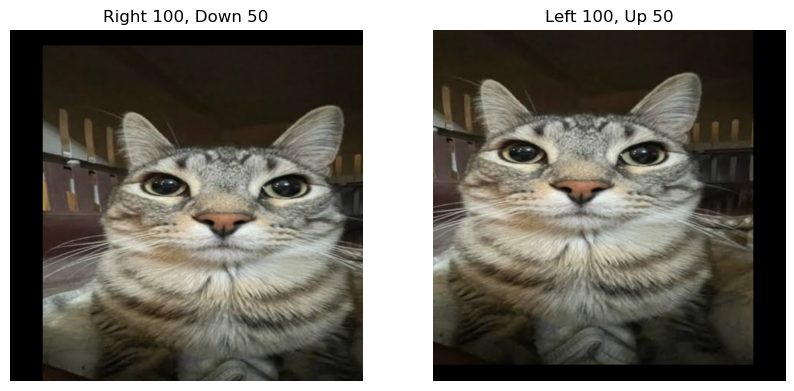

In [3]:
# 1. Move right 100, down 50
T1 = np.float32([[1, 0, 100], [0, 1, 50]])
translated1 = cv2.warpAffine(image, T1, (w, h))

# 2. Move left 100, up 50 (negative shift)
T2 = np.float32([[1, 0, -100], [0, 1, -50]])
translated2 = cv2.warpAffine(image, T2, (w, h))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(translated1, cv2.COLOR_BGR2RGB))
plt.title("Right 100, Down 50")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(translated2, cv2.COLOR_BGR2RGB))
plt.title("Left 100, Up 50")
plt.axis("off")

plt.show()

Step 2: Rotation

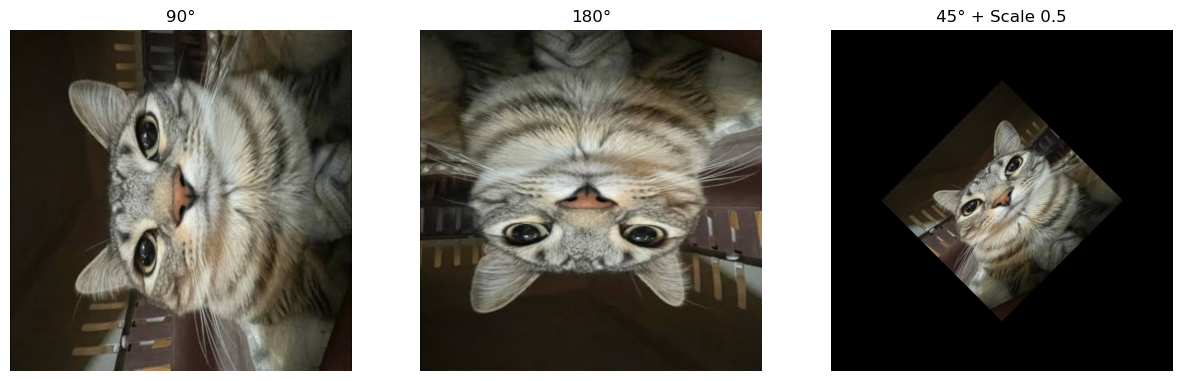

In [4]:
center = (w // 2, h // 2)

# 90 degrees
R1 = cv2.getRotationMatrix2D(center, 90, 1.0)
rotated_90 = cv2.warpAffine(image, R1, (w, h))

# 180 degrees
R2 = cv2.getRotationMatrix2D(center, 180, 1.0)
rotated_180 = cv2.warpAffine(image, R2, (w, h))

# 45 degrees with scaling 0.5
R3 = cv2.getRotationMatrix2D(center, 45, 0.5)
rotated_scaled = cv2.warpAffine(image, R3, (w, h))

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(rotated_90, cv2.COLOR_BGR2RGB))
plt.title("90°")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(rotated_180, cv2.COLOR_BGR2RGB))
plt.title("180°")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(rotated_scaled, cv2.COLOR_BGR2RGB))
plt.title("45° + Scale 0.5")
plt.axis("off")

plt.show()

Step 3: Scaling

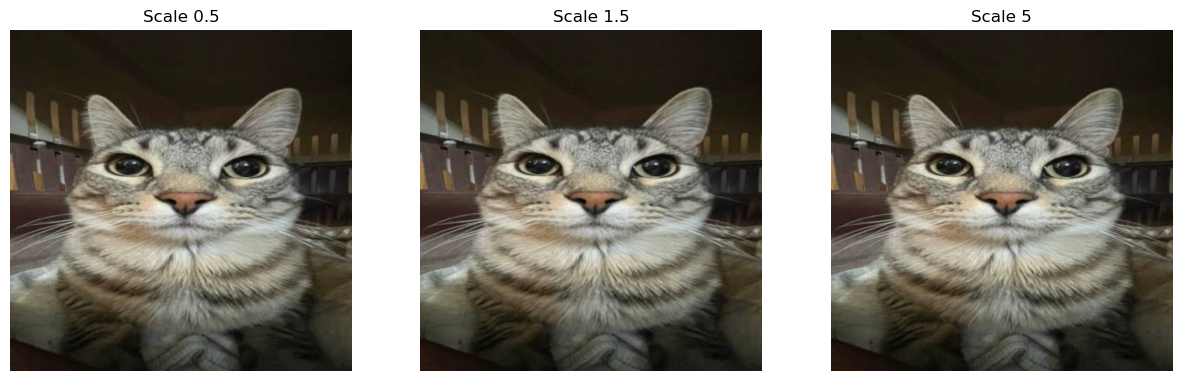

True

In [5]:
# 0.5x (shrink)
scaled_05 = cv2.resize(image, None, fx=0.5, fy=0.5)

# 1.5x
scaled_15 = cv2.resize(image, None, fx=1.5, fy=1.5)

# 5x (extreme scaling)
scaled_5 = cv2.resize(image, None, fx=5, fy=5)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(scaled_05, cv2.COLOR_BGR2RGB))
plt.title("Scale 0.5")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(scaled_15, cv2.COLOR_BGR2RGB))
plt.title("Scale 1.5")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(scaled_5, cv2.COLOR_BGR2RGB))
plt.title("Scale 5")
plt.axis("off")

plt.show()

# Save extreme scaling
cv2.imwrite("scaled_5.png", scaled_5)

Step 4: Shearing

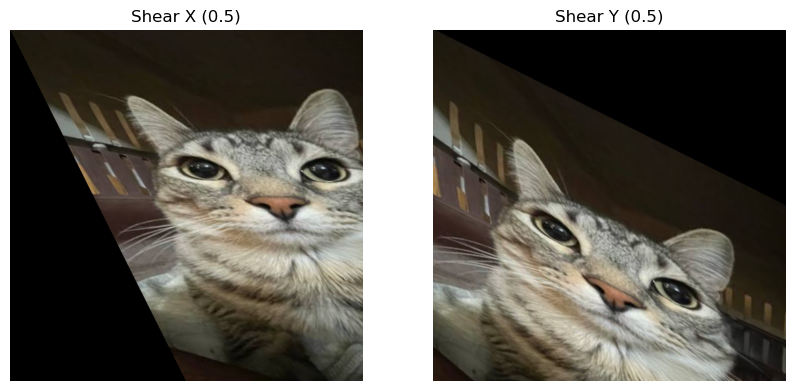

In [6]:
# Shear along X
m_x = 0.5
shear_x = np.float32([[1, m_x, 0],
                      [0, 1, 0]])

sheared_x = cv2.warpAffine(image, shear_x, (w, h))

# Shear along Y
m_y = 0.5
shear_y = np.float32([[1, 0, 0],
                      [m_y, 1, 0]])

sheared_y = cv2.warpAffine(image, shear_y, (w, h))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(sheared_x, cv2.COLOR_BGR2RGB))
plt.title("Shear X (0.5)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(sheared_y, cv2.COLOR_BGR2RGB))
plt.title("Shear Y (0.5)")
plt.axis("off")

plt.show()


Affine transformations are geometric operations that modify images while preserving straight lines and parallelism. They are widely used in computer vision, image processing, and deep learning for data augmentation.

From translation, I learned how pixel coordinates shift without changing the image structure. Rotation showed how images can change orientation around a fixed center while maintaining shape. Scaling demonstrated how resizing affects resolution and image quality, especially when using extreme factors where blurring or pixelation appears. Shearing illustrated how images can be distorted by slanting them along an axis, changing proportions but keeping lines straight.